### Business Understanding

### Metas del Proyecto
* **Objetivo:** Predecir las ventas diarias (`sales`) para 54 tiendas y 33 familias de productos durante un periodo de 16 días (16 al 31 de agosto de 2017).
* **Métrica de Éxito:** Minimizar el **RMSLE** (Error Cuadrático Medio Logarítmico), integrando variables externas como el precio del petróleo, feriados y promociones.

### Analytic Approach

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/store-sales-time-series-forecasting/oil.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/sample_submission.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/holidays_events.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/stores.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/train.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv
/kaggle/input/competitions/store-sales-time-series-forecasting/transactions.csv


### Data Requirements & Data Collection

In [2]:
import os 

path = '/kaggle/input/competitions/store-sales-time-series-forecasting/'

train = pd.read_csv( path + 'train.csv', parse_dates = ['date'])
stores = pd.read_csv(path + 'stores.csv')
oil = pd.read_csv(path + 'oil.csv', parse_dates = ['date'])



In [3]:
# mejoras

holidays = pd.read_csv(path + 'holidays_events.csv')
holidays = holidays[holidays['transferred'] == False]
holidays_unicos = holidays[['date']].drop_duplicates()
holidays_unicos['es_feriado'] = 1

In [4]:
print(train.head())
print(stores.head())
oil.head(10)


   id       date  store_nbr      family  sales  onpromotion
0   0 2013-01-01          1  AUTOMOTIVE    0.0            0
1   1 2013-01-01          1   BABY CARE    0.0            0
2   2 2013-01-01          1      BEAUTY    0.0            0
3   3 2013-01-01          1   BEVERAGES    0.0            0
4   4 2013-01-01          1       BOOKS    0.0            0
   store_nbr           city                           state type  cluster
0          1          Quito                       Pichincha    D       13
1          2          Quito                       Pichincha    D       13
2          3          Quito                       Pichincha    D        8
3          4          Quito                       Pichincha    D        9
4          5  Santo Domingo  Santo Domingo de los Tsachilas    D        4


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


### Data Understanding

In [5]:
oil = oil.set_index('date').resample('D').interpolate(method= 'linear').reset_index()
oil['precio_hace_14_dias'] = oil['dcoilwtico'].shift(14)
oil.head(10)

,date,dcoilwtico,precio_hace_14_dias
0,2013-01-01,NaN,NaN
1,2013-01-02,93.140000,NaN
2,2013-01-03,92.970000,NaN
3,2013-01-04,93.120000,NaN
4,2013-01-05,93.146667,NaN
5,2013-01-06,93.173333,NaN
6,2013-01-07,93.200000,NaN
7,2013-01-08,93.210000,NaN
8,2013-01-09,93.080000,NaN
9,2013-01-10,93.810000,NaN


In [6]:
print(train.shape)
stores.shape


(3000888, 6)


(54, 5)

### Data Preparation o Feature Engineering

In [7]:

holidays_unicos['date'] = pd.to_datetime(holidays_unicos['date'])


df = train.merge(stores, on='store_nbr', how='left')
df = df.merge(oil, on='date', how='left')
df = df.merge(holidays_unicos, on='date', how='left')

print(f"Forma del dataset unido: {df.shape}")
print(f"Valores nulos después del merge:\n{df.isnull().sum()}")


df['es_feriado'] = df['es_feriado'].fillna(0).astype(int)
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='bfill')
df['precio_hace_14_dias'] = df['precio_hace_14_dias'].fillna(method='bfill')

df.head()

Forma del dataset unido: (3000888, 13)
Valores nulos después del merge:
id                           0
date                         0
store_nbr                    0
family                       0
sales                        0
onpromotion                  0
city                         0
state                        0
type                         0
cluster                      0
dcoilwtico                1782
precio_hace_14_dias      26730
es_feriado             2567862
dtype: int64


/tmp/ipykernel_16/2133854990.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['dcoilwtico'] = df['dcoilwtico'].fillna(method='bfill')
/tmp/ipykernel_16/2133854990.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['precio_hace_14_dias'] = df['precio_hace_14_dias'].fillna(method='bfill')


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,precio_hace_14_dias,es_feriado
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.14,93.14,1
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,93.14,93.14,1
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,93.14,93.14,1
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,93.14,93.14,1
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,93.14,93.14,1


In [8]:
df = df.sort_values(['store_nbr', 'family', 'date'])
df['promocion_ayer'] = df.groupby(['store_nbr', 'family'])['onpromotion'].shift(1)
df['promocion_ayer'] = df['promocion_ayer'].fillna(0)

### Data Preparation / Feature Engineering.

In [9]:
def extraer_caract_tiempo(data):
    
    data['day_of_week'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data['year'] = data['date'].dt.year
    data['day_of_month'] = data['date'].dt.day

    data['is_payday'] = ((data['day_of_month']==15)| (data['date'].dt.is_month_end))
    data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)
    return data

In [10]:
df = extraer_caract_tiempo(df)
#print(df.head(10))
print(df[['date','day_of_week', 'is_payday', 'is_weekend']].head(15))
df.head()

            date  day_of_week  is_payday  is_weekend
0     2013-01-01            1      False           0
1782  2013-01-02            2      False           0
3564  2013-01-03            3      False           0
5346  2013-01-04            4      False           0
7128  2013-01-05            5      False           1
8910  2013-01-06            6      False           1
10692 2013-01-07            0      False           0
12474 2013-01-08            1      False           0
14256 2013-01-09            2      False           0
16038 2013-01-10            3      False           0
17820 2013-01-11            4      False           0
19602 2013-01-12            5      False           1
21384 2013-01-13            6      False           1
23166 2013-01-14            0      False           0
24948 2013-01-15            1       True           0


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,precio_hace_14_dias,es_feriado,promocion_ayer,day_of_week,month,year,day_of_month,is_payday,is_weekend
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,93.140000,93.14,1,0.0,1,1,2013,1,False,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0,Quito,Pichincha,D,13,93.140000,93.14,0,0.0,2,1,2013,2,False,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,92.970000,93.14,0,0.0,3,1,2013,3,False,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0,Quito,Pichincha,D,13,93.120000,93.14,0,0.0,4,1,2013,4,False,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0,Quito,Pichincha,D,13,93.146667,93.14,1,0.0,5,1,2013,5,False,1


### Data Understanding

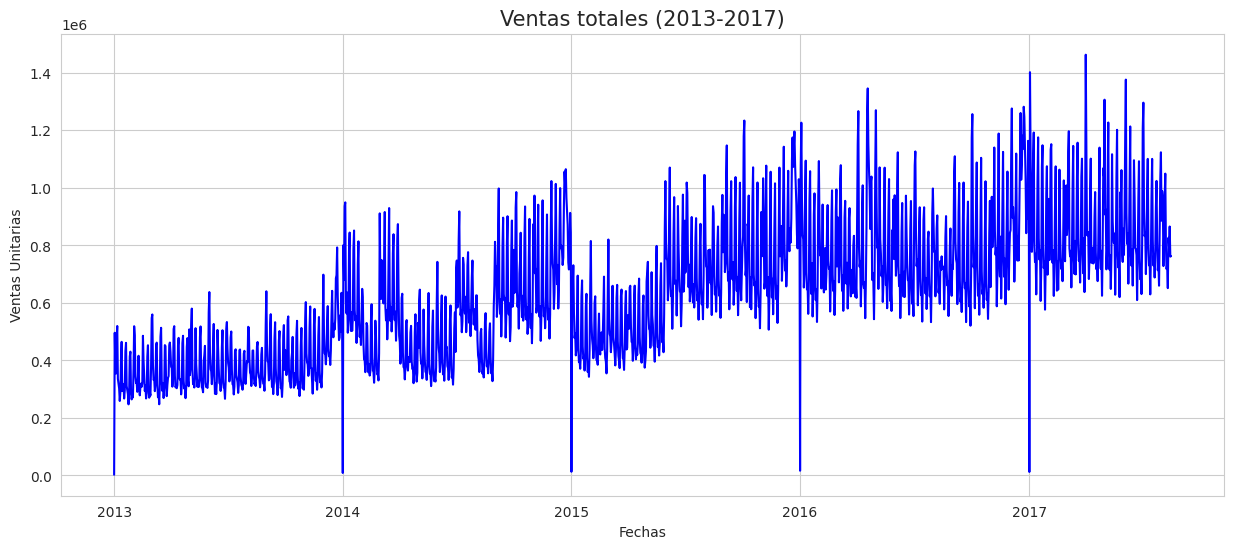

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,6))
sns.set_style('whitegrid')

daily_sales = df.groupby('date')['sales'].sum().reset_index()
sns.lineplot(data= daily_sales, x= 'date', y= 'sales', color = 'blue')
plt.title('Ventas totales (2013-2017)', fontsize= 15)
plt.xlabel('Fechas')
plt.ylabel('Ventas Unitarias')
plt.show()

/tmp/ipykernel_16/1459825084.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette='viridis')


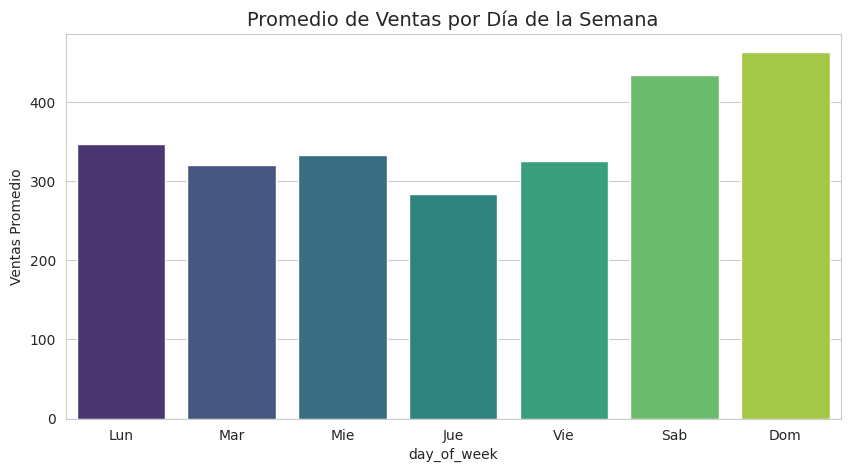

In [12]:
plt.figure(figsize=(10, 5))

weekly_pattern = df.groupby('day_of_week')['sales'].mean()

sns.barplot(x=weekly_pattern.index, y=weekly_pattern.values, palette='viridis')
plt.title('Promedio de Ventas por Día de la Semana', fontsize=14)
plt.xticks(ticks=[0,1,2,3,4,5,6], labels=['Lun', 'Mar', 'Mie', 'Jue', 'Vie', 'Sab', 'Dom'])
plt.ylabel('Ventas Promedio')
plt.show()

/tmp/ipykernel_16/2181054716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payday_pattern.index, y=payday_pattern.values, palette='Set2')


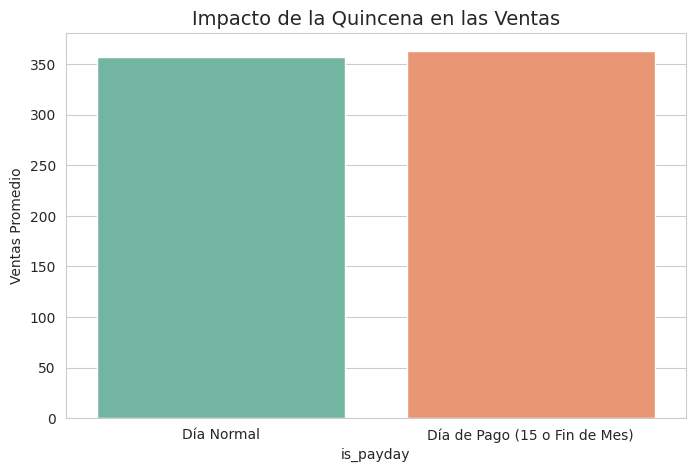

In [13]:
plt.figure(figsize=(8,5))
payday_pattern = df.groupby('is_payday')['sales'].mean()

sns.barplot(x=payday_pattern.index, y=payday_pattern.values, palette='Set2')
plt.title('Impacto de la Quincena en las Ventas', fontsize=14)
plt.xticks(ticks=[0, 1], labels=['Día Normal', 'Día de Pago (15 o Fin de Mes)'])
plt.ylabel('Ventas Promedio')
plt.show()

/tmp/ipykernel_16/3025923296.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_familias.values, y=top_familias.index, palette='magma')


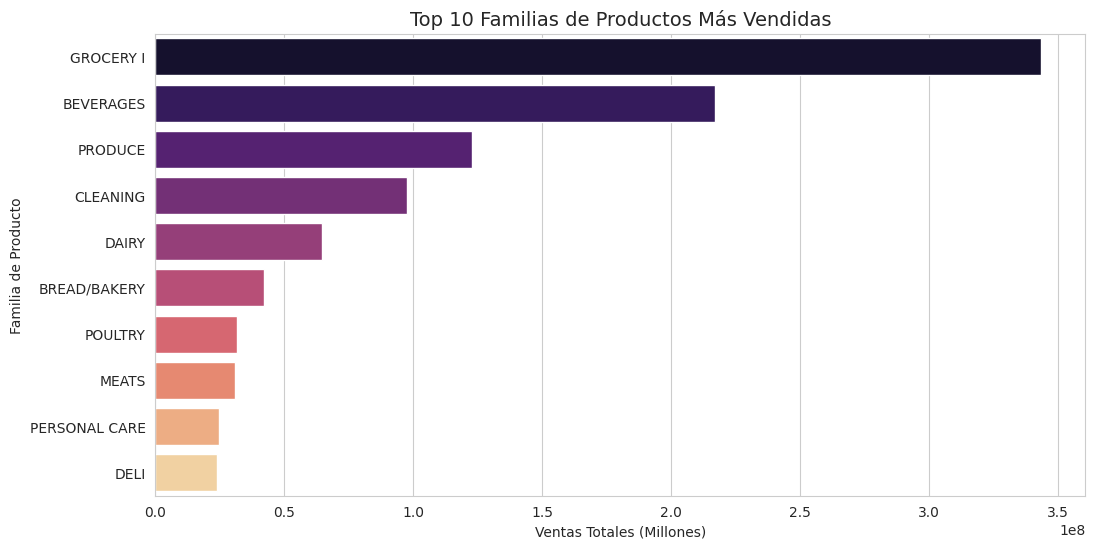

In [14]:
plt.figure(figsize=(12, 6))

top_familias = df.groupby('family')['sales'].sum().sort_values(ascending= False).head(10)

sns.barplot(x=top_familias.values, y=top_familias.index, palette='magma')
plt.title('Top 10 Familias de Productos Más Vendidas', fontsize=14)
plt.xlabel('Ventas Totales (Millones)')
plt.ylabel('Familia de Producto')
plt.show()

### Data Preparation

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['family_encoded'] = le.fit_transform(df['family'])


features = [
    'store_nbr', 'family_encoded', 'day_of_week', 'month', 'year', 
    'is_payday', 'is_weekend', 'es_feriado', 'onpromotion', 
    'promocion_ayer', 'dcoilwtico', 'precio_hace_14_dias'
]
target = 'sales'

train_data = df[df['date'] < '2017-08-01']
valid_data = df[(df['date'] >= '2017-08-01') & (df['date'] <= '2017-08-15')]

X_train = train_data[features]
y_train = train_data[target]
y_train_log = np.log1p(y_train)

X_valid = valid_data[features]
y_valid = valid_data[target]



In [16]:
print(X_train.shape, X_valid.shape)

(2974158, 12) (26730, 12)


### MODELING

In [17]:
from sklearn.metrics import mean_squared_log_error
import numpy as np

#### Usando LightGBM

In [18]:
import lightgbm as lgb 

modelo = lgb.LGBMRegressor(
    n_estimators = 2000,
    learning_rate = 0.05,
    max_depth = 20,
    num_leaves = 127,
    min_child_samples = 50,
    random_state = 42,
    n_jobs = -1
)

modelo.fit(X_train, y_train_log)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.165054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1039
[LightGBM] [Info] Number of data points in the train set: 2974158, number of used features: 12
[LightGBM] [Info] Start training from score 2.920052


LGBMRegressor(learning_rate=0.05, max_depth=20, min_child_samples=50,
              n_estimators=2000, n_jobs=-1, num_leaves=127, random_state=42)

In [19]:
predicciones_log = modelo.predict(X_valid)


predicciones = np.expm1(predicciones_log)


predicciones = np.clip(predicciones, 0, None)


rmsle = np.sqrt(mean_squared_log_error(y_valid, predicciones))



In [20]:
rmsle

np.float64(0.4846053804548766)

## Test

In [21]:



test = pd.read_csv('/kaggle/input/competitions/store-sales-time-series-forecasting/test.csv', parse_dates=['date'])
ids_test = test['id'] 

df_test = test.merge(stores, on='store_nbr', how='left')
df_test = df_test.merge(oil, on='date', how='left')
df_test = df_test.merge(holidays_unicos, on='date', how='left')

df_test['es_feriado'] = df_test['es_feriado'].fillna(0).astype(int)
df_test['dcoilwtico'] = df_test['dcoilwtico'].fillna(method='ffill') # Rellenar precio del petróleo
df_test['precio_hace_14_dias'] = df_test['precio_hace_14_dias'].fillna(method='ffill')

df_test = extraer_caract_tiempo(df_test)

df_test = df_test.sort_values(['store_nbr', 'family', 'date'])
df_test['promocion_ayer'] = df_test.groupby(['store_nbr', 'family'])['onpromotion'].shift(1).fillna(0)


df_test['family_encoded'] = le.transform(df_test['family'])


df_test = df_test.sort_values('id')

X_test_final = df_test[features]

/tmp/ipykernel_16/109595544.py:9: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_test['dcoilwtico'] = df_test['dcoilwtico'].fillna(method='ffill') # Rellenar precio del petróleo
/tmp/ipykernel_16/109595544.py:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_test['precio_hace_14_dias'] = df_test['precio_hace_14_dias'].fillna(method='ffill')


In [22]:

preds_log_test = modelo.predict(X_test_final)


preds_finales = np.expm1(preds_log_test)
preds_finales = np.clip(preds_finales, 0, None) # Asegurar que no haya ventas negativas


submission = pd.DataFrame({
    'id': ids_test,
    'sales': preds_finales
})


submission.to_csv('submission.csv', index=False)
print("¡Archivo submission.csv creado con éxito!")

¡Archivo submission.csv creado con éxito!


In [23]:
# --- PRUEBA DE CORDURA (SANITY CHECK) ---

print("=== PROMEDIO DE VENTAS DIARIAS ===")
print(f"1. Lo que el modelo aprendió (Train): {np.expm1(y_train_log).mean():.2f}")
print(f"2. Lo que el modelo predijo en Validación: {predicciones.mean():.2f}")
print(f"3. Lo que el modelo está prediciendo para el Futuro (Test): {preds_finales.mean():.2f}")

print("\n=== VALORES MÁXIMOS ===")
print(f"Venta máxima histórica: {np.expm1(y_train_log).max():.2f}")
print(f"Venta máxima predicha futuro: {preds_finales.max():.2f}")

print("\n=== REVISIÓN DE NULOS EN EL EXAMEN ===")
print(X_test_final.isnull().sum())

=== PROMEDIO DE VENTAS DIARIAS ===
1. Lo que el modelo aprendió (Train): 356.81
2. Lo que el modelo predijo en Validación: 447.78
3. Lo que el modelo está prediciendo para el Futuro (Test): 453.29

=== VALORES MÁXIMOS ===
Venta máxima histórica: 124717.00
Venta máxima predicha futuro: 16757.21

=== REVISIÓN DE NULOS EN EL EXAMEN ===
store_nbr              0
family_encoded         0
day_of_week            0
month                  0
year                   0
is_payday              0
is_weekend             0
es_feriado             0
onpromotion            0
promocion_ayer         0
dcoilwtico             0
precio_hace_14_dias    0
dtype: int64


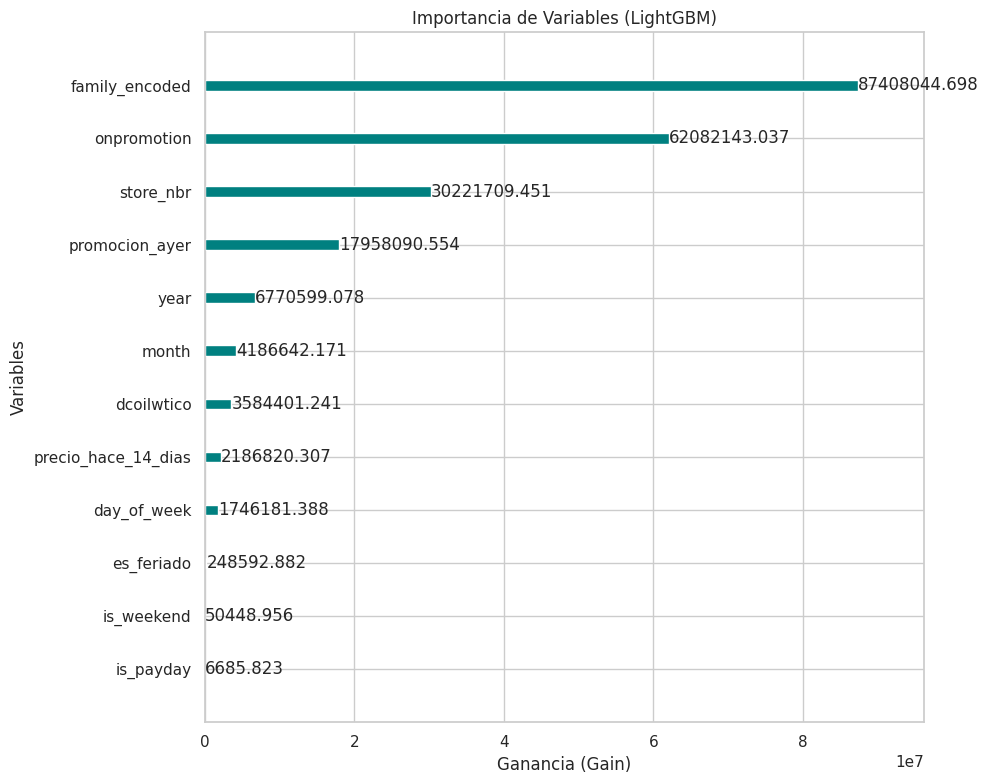

In [24]:
import os
os.makedirs('images', exist_ok=True)

import matplotlib.pyplot as plt
import lightgbm as lgb
import seaborn as sns

# Configurar el estilo visual (para que se vea más profesional)
sns.set_theme(style="whitegrid")

# Crear y guardar la gráfica de importancia
fig, ax = plt.subplots(figsize=(10, 8))
lgb.plot_importance(
    modelo, 
    max_num_features=15, # Muestra el Top 15 de variables más importantes
    importance_type='gain', # 'gain' mide cuánto aportó la variable para mejorar el modelo
    title='Importancia de Variables (LightGBM)',
    xlabel='Ganancia (Gain)',
    ylabel='Variables',
    ax=ax,
    color='teal'
)

plt.tight_layout()
# Esto guarda la gráfica en tu computadora
plt.savefig('images/feature_importance.png', dpi=300) 
plt.show()